In [ ]:
from nwb_utils import NWBUtils
from ephys_behavior_visualization import plot_session_spike_raster
# Read combined

# 'ecephys_781471_2025-03-27_13-39-06_sorted_2025-03-31_11-52-53',
#  'ecephys_781471_2025-03-28_15-06-14_sorted_2025-03-31_14-10-16',

nwb_data,a = NWBUtils.combine_nwb(session_name="ecephys_776293_2025-02-18_12-51-36_sorted_2025-03-30_05-50-33")

plot_session_spike_raster(
    nwb_data,
    time_window=(nwb_data.trials[51]['start_time']+3, nwb_data.trials[51]['stop_time']),
    probes=["ProbeA","ProbeB","ProbeC"],  # must match values in units['device_name']
    events={"go_cue": "go_cue"},
    save_figure=True
)





In [ ]:
from behavior_utils import get_fitted_model_names
get_fitted_model_names(session_name=nwb_data.session_id)

Found ephys NWB: /root/capsule/data/ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25/nwb/ecephys_753124_2024-12-10_17-24-56_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_753124_2024-12-10_17-24-56_sorted_2024-12-13_09-48-25/nwb/ecephys_753124_2024-12-10_17-24-56_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753124_2024-12-10_17-24-56.nwb


/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:583: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/753124_2024-12-10_17-24-56.nwb
Successfully appended units table to behavior NWB.
Number of units passing QC: 528
[OK] Figure saved → /root/capsule/results/PSTH_quantiles.png


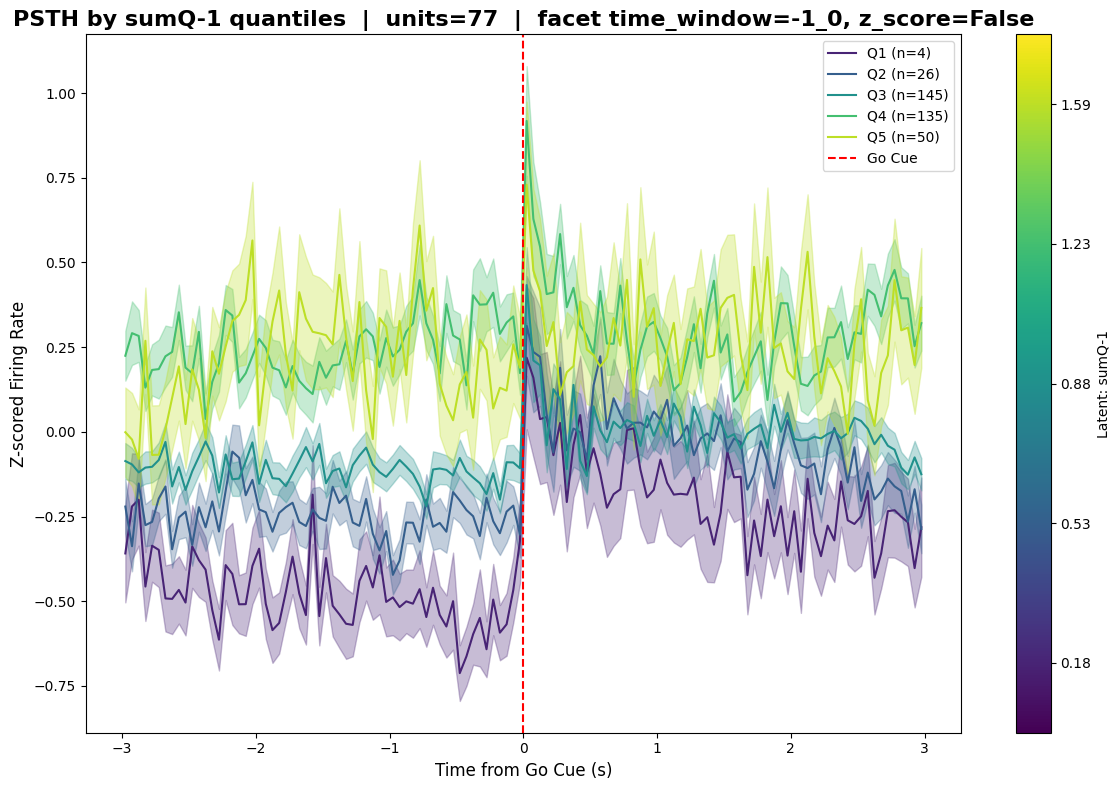

Found ephys NWB: /root/capsule/data/ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58/nwb/ecephys_753125_2024-10-09_10-50-19_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58/nwb/ecephys_753125_2024-10-09_10-50-19_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/753125_2024-10-09_10-50-19.nwb


/opt/conda/lib/python3.10/site-packages/hdmf/spec/namespace.py:583: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
core - cached version: 2.6.0-alpha, loaded version: 2.7.0
The loaded extension(s) may not be compatible with the cached extension(s) in the file. Please check the extension documentation and ignore this warning if these versions are compatible.
  self.warn_for_ignored_namespaces(ignored_namespaces)


Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/753125_2024-10-09_10-50-19.nwb
Successfully appended units table to behavior NWB.
Number of units passing QC: 248
[OK] Figure saved → /root/capsule/results/PSTH_quantiles.png


KeyboardInterrupt: 

In [3]:
from nwb_utils import NWBUtils
from ephys_behavior_visualization import plot_session_spike_raster
# Read combined

# 'ecephys_781471_2025-03-27_13-39-06_sorted_2025-03-31_11-52-53',
#  'ecephys_781471_2025-03-28_15-06-14_sorted_2025-03-31_14-10-16',
from general_utils import find_ephys_sessions
sessions=find_ephys_sessions()

for session_name in sessions[2]:
    #nwb_data,a = NWBUtils.combine_nwb(session_name="ecephys_776293_2025-02-18_12-51-36_sorted_2025-03-30_05-50-33")
    nwb_data,a = NWBUtils.combine_nwb(session_name=session_name)


    from plot_quantile import plot_quantiles_adapted

    #ARDL_model-ForagingCompareThreshold-reward-g2-s0-d0-pval
    #ARDL_model-ForagingCompareThreshold-value-1-g2-s0-d0-pval
    #simple_LR-QLearning_L2F1_CK1_softmax-sumQ-1-g1-s0-d0-pval


    plot_quantiles_adapted(
        nwb_data,
        zarr_path="/root/capsule/results/sig_dir_all_sessions.zarr",
        model="ARDL_model",
        variable="QLearning_L2F1_CK1_softmax-sumQ-1",      # must match the suffix used in the summary columns
        time_window_label="-1_0",           # facet to match the summary
        z_score_flag=False,                  # same facet
        p_value_threshold=0.05,
        shift_tag="s0",
        direction=0,
        group=5,                         # None → uses min p across groups
        slope_selection=("positive","negative"),
        behavior_model="QLearning_L2F1_CK1_softmax",
        latent_name="sumQ-1",
        align_event="go_cue",
        time_window=(-3, 3),
        bin_size=0.05,
        z_score_psth=True,
        smooth_sigma=None,
        normalize_to_baseline=False,
        baseline_period=(-1.0, 0.0),
        unit_indices=None,
        probes=["ProbeA","ProbeB","ProbeC"],        # optional filtering via units['device_name']
        quantiles_num=5,
        save_folder="/root/capsule/results",
        save_basename="PSTH_quantiles",
        save_format="png",
)

In [4]:
session_name

'ecephys_753125_2024-10-09_10-50-19_sorted_2024-11-09_20-03-58'

Found ephys NWB: /root/capsule/data/ecephys_764769_2024-12-13_15-41-07_sorted_2024-12-17_18-00-23/nwb/ecephys_764769_2024-12-13_15-41-07_experiment1_recording1.nwb
Successfully read ephys NWB from: /root/capsule/data/ecephys_764769_2024-12-13_15-41-07_sorted_2024-12-17_18-00-23/nwb/ecephys_764769_2024-12-13_15-41-07_experiment1_recording1.nwb
Found behavior NWB: /root/capsule/data/behavior_nwb/behavior_764769_2024-12-13_15-41-07.nwb
Successfully read behavior NWB from: /root/capsule/data/behavior_nwb/behavior_764769_2024-12-13_15-41-07.nwb
Successfully appended units table to behavior NWB.
Number of units passing QC: 608
[OK] Figure saved → /root/capsule/results/PSTH_quantiles.png


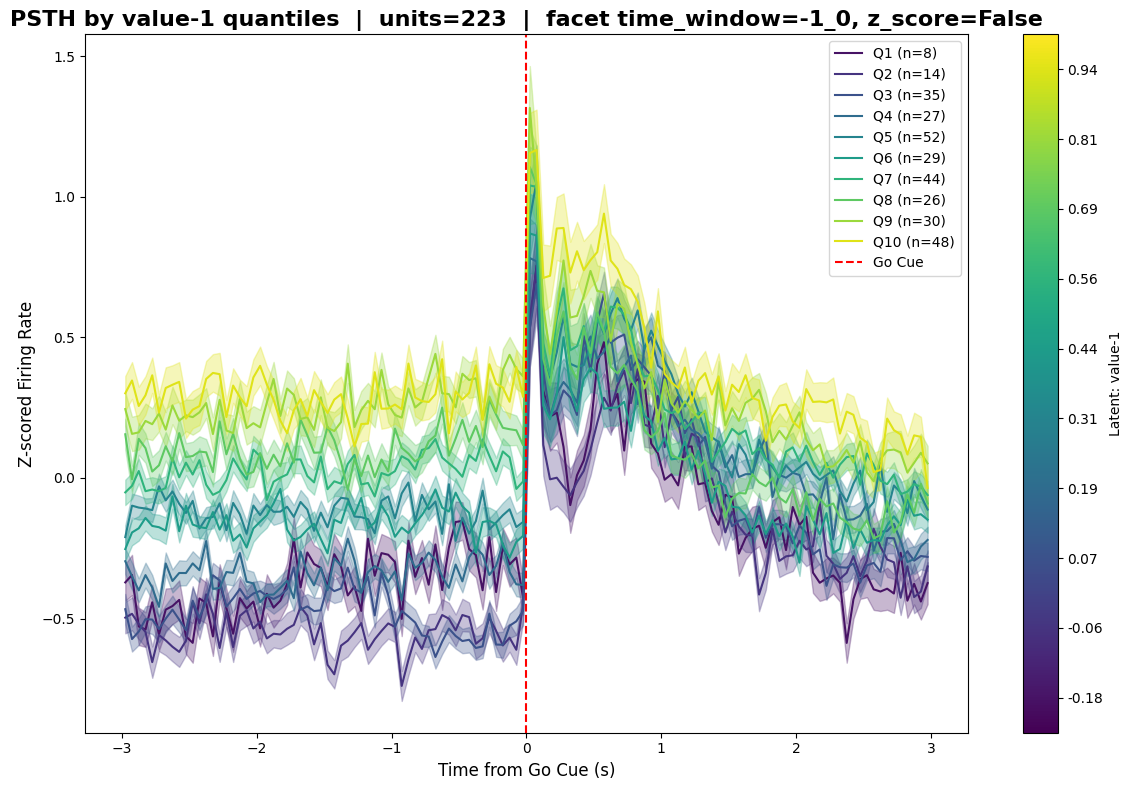

In [11]:
from nwb_utils import NWBUtils
from ephys_behavior_visualization import plot_session_spike_raster
# Read combined
from plot_quantile import plot_quantiles_adapted
from general_utils import find_ephys_sessions
sessions=find_ephys_sessions()
# 'ecephys_781471_2025-03-27_13-39-06_sorted_2025-03-31_11-52-53',
#  'ecephys_781471_2025-03-28_15-06-14_sorted_2025-03-31_14-10-16',
#for session_name in sessions[2]:
#    nwb_data,a = NWBUtils.combine_nwb(session_name=session_name)
    #nwb_data,a = NWBUtils.combine_nwb(session_name=session_name)

    #nwb_data,a = NWBUtils.combine_nwb(session_name="ecephys_776293_2025-02-18_12-51-36_sorted_2025-03-30_05-50-33")
    #nwb_data,a = NWBUtils.combine_nwb(session_name="ecephys_764769_2024-12-11_18-21-49_sorted_2024-12-13_10-04-48")

    #ARDL_model-ForagingCompareThreshold-reward-g2-s0-d0-pval
    #ARDL_model-ForagingCompareThreshold-value-1-g2-s0-d0-pval
    #ARDL_model-QLearning_L2F1_CK1_softmax-chosenQ-1-g0-s-1-d0-coef
nwb_data,a = NWBUtils.combine_nwb(session_name="ecephys_764769_2024-12-13_15-41-07_sorted_2024-12-17_18-00-23")

plot_quantiles_adapted(
    nwb_data,
    zarr_path="/root/capsule/results/sig_dir_all_sessions.zarr",
    model="simple_LR",
    variable="ForagingCompareThreshold-value-1",      # must match the suffix used in the summary columns
    time_window_label="-1_0",           # facet to match the summary
    z_score_flag=False,                  # same facet
    p_value_threshold=0.05,
    shift_tag="s0",
    direction=0,
    group=7,                         # None → uses min p across groups
    slope_selection=("positive","negative"),
    behavior_model="ForagingCompareThreshold",
    latent_name="value-1",
    align_event="go_cue",
    time_window=(-3, 3),
    bin_size=0.05,
    z_score_psth=True,
    smooth_sigma=None,
    normalize_to_baseline=False,
    baseline_period=(-1.0, 0.0),
    unit_indices=None,
    probes=["ProbeA","ProbeB","ProbeC"],        # optional filtering via units['device_name']
    quantiles_num=10,
    save_folder="/root/capsule/results",
    save_basename="PSTH_quantiles",
    save_format="png",
)

In [ ]:
nwb_data.session_id